# Actividad 5.2 — Regresión Lineal Simple
## Base de datos: Ventas por Asesor (GAC)

### Paso 1: Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Paso 2: Cargar datos

In [2]:
# from google.colab import files
# files.upload()

data_va = pd.read_csv('ventas_por_asesor_sin_nulos.csv')
data_va.head()

,Nombre_Vendedor,Ventas_2024-02,Ventas_2024-03,Ventas_2024-04,Ventas_2024-05,Ventas_2024-06,Ventas_2024-07,Ventas_2024-08,Ventas_2024-09,Ventas_2024-10,...,Ventas_2026-06,Ventas_2026-07,Col_811,Raking,Acum_2024,Ranking_2024,Acum_2025,Ranking_2025,Acum_2026,Ranking_2026
0,PEDRO GONZALEZ ESPINDOLA,0.0,0.0,1.0,2.0,0.0,7.0,2.0,3.0,3.0,...,4.0,0.0,88.0,0.0,22,0.0,45,2.0,21,0.0
1,VICTOR MANUEL SANCHEZ ARRO,0.0,0.0,0.0,0.0,1.0,1.0,3.0,0.0,2.0,...,3.0,2.0,88.0,0.0,11,0.0,51,0.0,26,0.0
2,MIGUEL ANGEL SONDEREGGER,0.0,0.0,0.0,1.0,2.0,7.0,5.0,2.0,2.0,...,0.0,0.0,28.0,6.0,27,1.0,1,25.0,0,17.0
3,JOSE ANTONIO LICONA MENDE,1.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0,2.0,...,9.0,1.0,98.0,1.0,10,4.0,35,4.0,53,1.0
4,JAIME GONZALEZ CORONA,0.0,2.0,3.0,5.0,2.0,3.0,3.0,3.0,4.0,...,0.0,0.0,25.0,8.0,25,2.0,0,30.0,0,17.0


### Paso 3: Nulos y tipos numéricos

In [3]:
print(data_va.isnull().sum())

cualitativas_va = data_va[['Nombre_Vendedor']]
cuantitativas_va = data_va.drop(columns=['Nombre_Vendedor'])

Nombre_Vendedor    0
Ventas_2024-02     0
Ventas_2024-03     0
Ventas_2024-04     0
Ventas_2024-05     0
Ventas_2024-06     0
Ventas_2024-07     0
Ventas_2024-08     0
Ventas_2024-09     0
Ventas_2024-10     0
Ventas_2024-11     0
Ventas_2024-12     0
Ventas_2025-01     0
Ventas_2025-02     0
Ventas_2025-03     0
Ventas_2025-04     0
Ventas_2025-05     0
Ventas_2025-06     0
Ventas_2025-07     0
Ventas_2025-08     0
Ventas_2025-09     0
Ventas_2025-10     0
Ventas_2025-11     0
Ventas_2025-12     0
Ventas_2026-01     0
Ventas_2026-02     0
Ventas_2026-03     0
Ventas_2026-04     0
Ventas_2026-05     0
Ventas_2026-06     0
Ventas_2026-07     0
Col_811            0
Raking             0
Acum_2024          0
Ranking_2024       0
Acum_2025          0
Ranking_2025       0
Acum_2026          0
Ranking_2026       0
dtype: int64


### Paso 4: Outliers (método de desviación estándar)

In [4]:
lim_sup_va = cuantitativas_va.mean() + 3*cuantitativas_va.std()
lim_inf_va = cuantitativas_va.mean() - 3*cuantitativas_va.std()
data_clean_va = cuantitativas_va[(cuantitativas_va <= lim_sup_va) & (cuantitativas_va >= lim_inf_va)]
data_clean_va = data_clean_va.fillna(round(data_clean_va.mean(), 1))
print('Nulos restantes:', data_clean_va.isnull().sum().sum())

Nulos restantes: 0


### Paso 5: Matriz de correlación

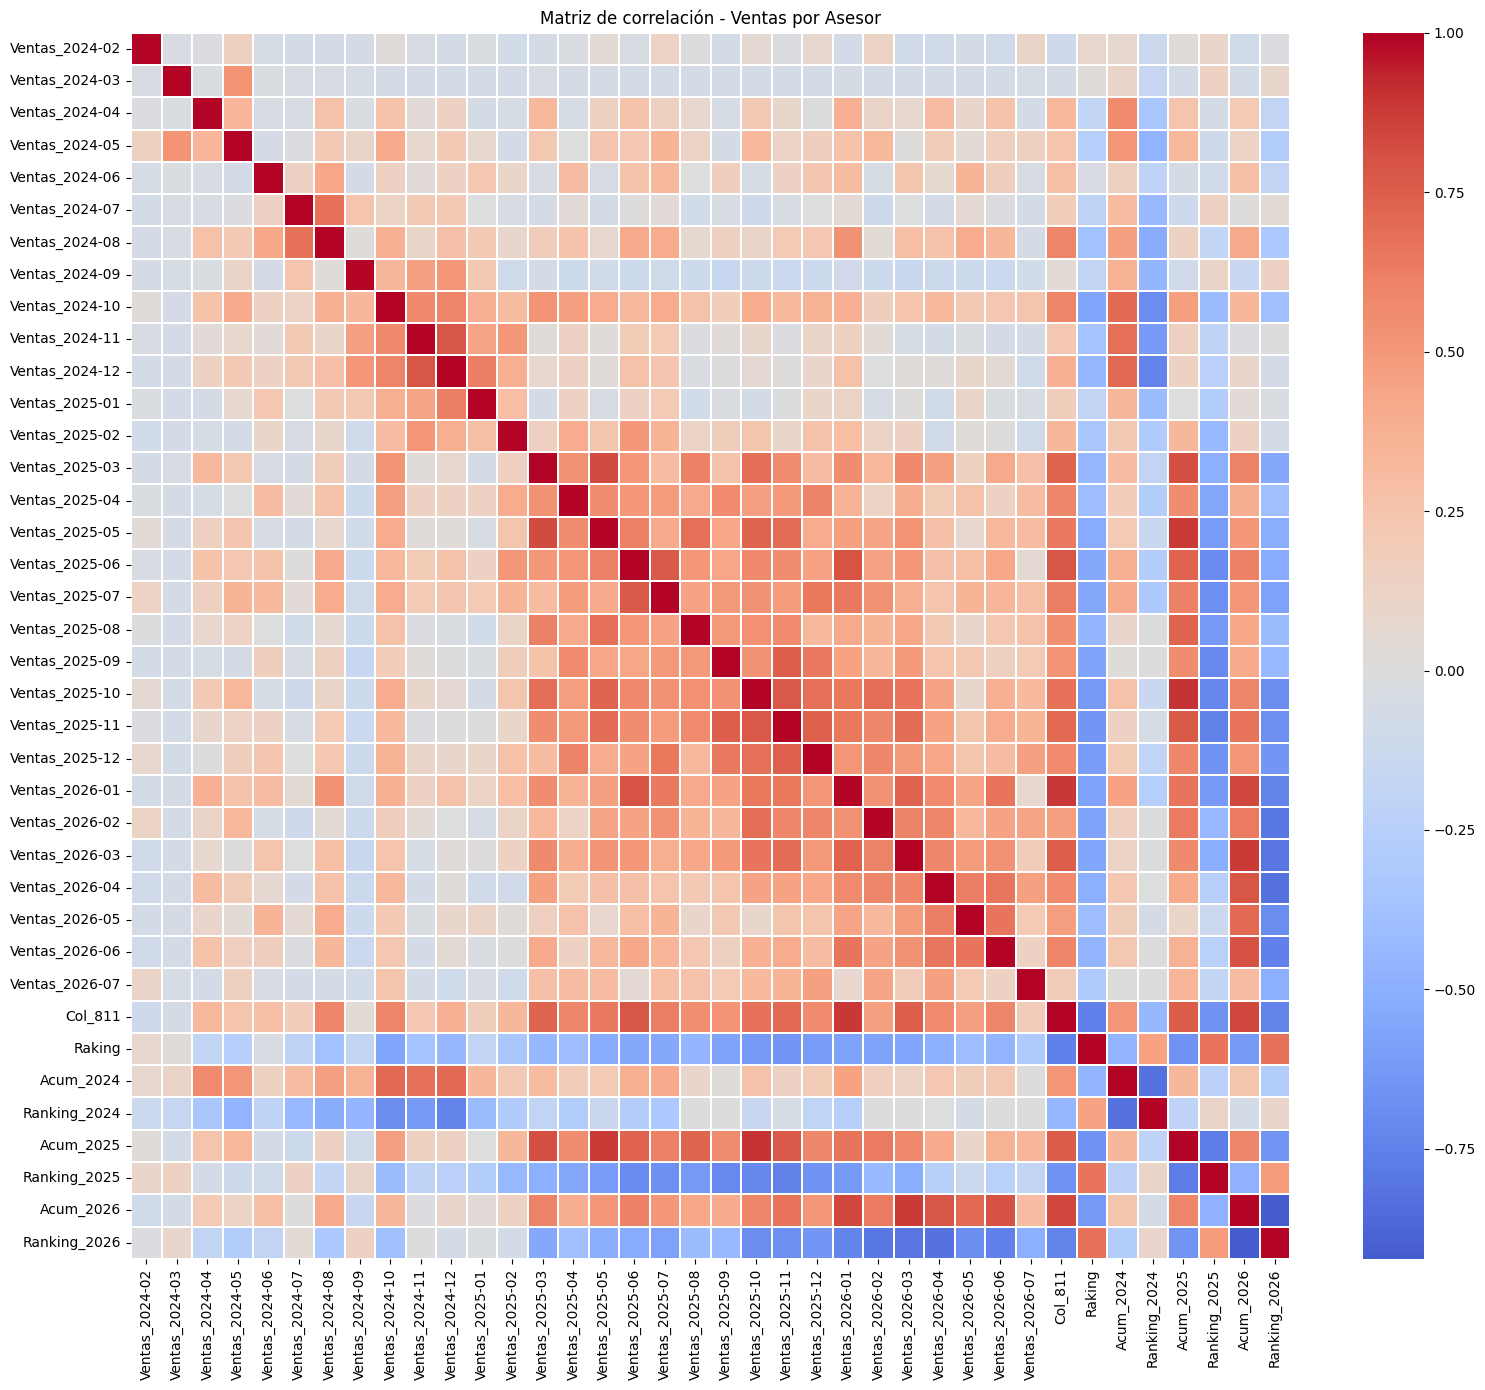

In [5]:
corr_va = data_clean_va.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr_va, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Matriz de correlación - Ventas por Asesor')
plt.tight_layout()
plt.savefig('heatmap_ventas.png', dpi=150)
plt.show()

### Paso 6: Pares de variables más correlacionadas

In [6]:
pairs_va = corr_va.where(np.triu(np.ones(corr_va.shape), k=1).astype(bool)).stack()
top_pairs_va = pairs_va.reindex(pairs_va.abs().sort_values(ascending=False).index).head(10)
print(top_pairs_va)

Acum_2026       Ranking_2026     -0.922496
Ventas_2025-10  Acum_2025         0.897529
Ventas_2026-01  Col_811           0.887163
Ventas_2026-03  Acum_2026         0.877335
Ventas_2025-05  Acum_2025         0.873175
Ventas_2026-01  Acum_2026         0.839200
Col_811         Acum_2026         0.838478
Ventas_2025-03  Ventas_2025-05    0.822524
Acum_2024       Ranking_2024     -0.819643
Ventas_2026-04  Ranking_2026     -0.819139
dtype: float64


### Paso 7: Regresión lineal simple — Acum_2025 vs Acum_2026
Se eligió este par porque fue el más correlacionado entre variables de negocio comparables (ventas acumuladas de un año vs. el siguiente), y permite estimar el desempeño 2026 a partir de 2025.

Ecuación: Acum_2026 = 0.3150 * Acum_2025 + 1.4809
R² = 0.3519


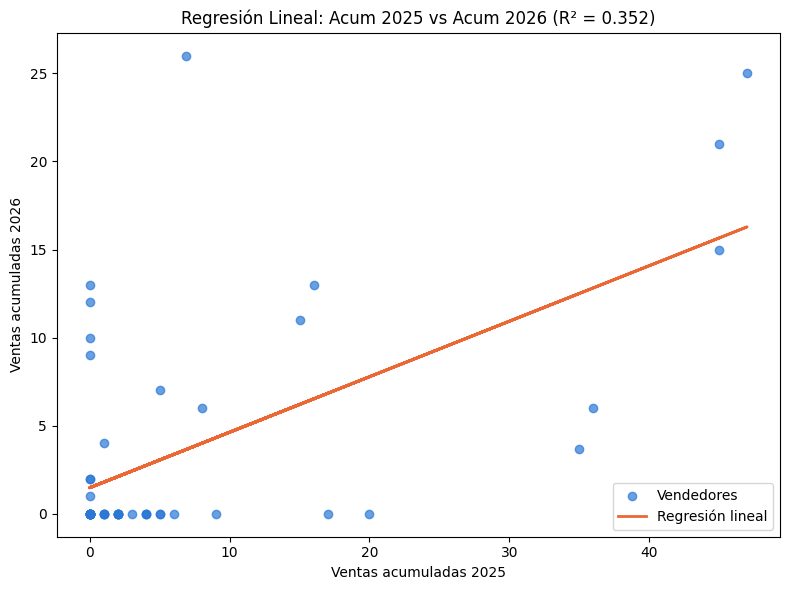

In [7]:
x_va = data_clean_va[['Acum_2025']].values
y_va = data_clean_va['Acum_2026'].values

modelo_va = LinearRegression().fit(x_va, y_va)
y_pred_va = modelo_va.predict(x_va)
r2_va = r2_score(y_va, y_pred_va)

print(f"Ecuación: Acum_2026 = {modelo_va.coef_[0]:.4f} * Acum_2025 + {modelo_va.intercept_:.4f}")
print(f"R\u00b2 = {r2_va:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(x_va, y_va, color='#2a78d6', alpha=0.7, label='Vendedores')
plt.plot(x_va, y_pred_va, color='#eb6834', linewidth=2, label='Regresión lineal')
plt.xlabel('Ventas acumuladas 2025')
plt.ylabel('Ventas acumuladas 2026')
plt.title(f'Regresión Lineal: Acum 2025 vs Acum 2026 (R\u00b2 = {r2_va:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('regresion_ventas.png', dpi=150)
plt.show()